## Commercial Jet Classifier for Mobile (local GPU training)

This notebook builds an aircraft **model-family** classifier that can be exported and run on a phone. It trains **locally on your GPU** and uses the up-to-date [`nyuuzyou/aircraft-images`](https://huggingface.co/datasets/nyuuzyou/aircraft-images) dataset (165k captioned aircraft photos, CC0 captions).

**Pipeline**
1. **Download** a configurable subset of the dataset shards from Hugging Face.
2. **Parse the free-text captions** into commercial-jet *model-family* labels (e.g. `Airbus A320`, `Boeing 737`). Non-commercial aircraft (military, GA, props, biplanes) are filtered out.
3. **Phase 1 – Detection:** use YOLO to crop each photo to the aircraft (done once, cached to disk).
4. **Phase 2 – Classification:** fine-tune MobileNetV4 on the cropped, labelled images.
5. **Export** to TorchScript / ONNX (+ optional TFLite) for mobile deployment.

> This replaces the original Colab + FGVC-Aircraft workflow. There is now a single training stage on the newer dataset (ImageNet-pretrained MobileNetV4 is the warm start), so the old FGVC and Kaggle "Stage 2" sections are gone.

### 1. Local environment & dependencies

Run this once to install everything into the current kernel's environment. The `torch` / `torchvision` line pulls the **CUDA 12.1** build so training runs on your NVIDIA GPU (e.g. RTX 2080). If you'd rather manage the venv yourself, run the same `pip install` commands in a terminal instead.

If you hit an out-of-memory error later on an 8 GB GPU, lower `BATCH_SIZE` in the config cell.

In [ ]:
# Install dependencies (safe to re-run). Uses the CUDA 12.1 PyTorch build.
%pip install --index-url https://download.pytorch.org/whl/cu121 torch torchvision
%pip install ultralytics huggingface_hub hf_xet==1.4.2 zstandard pillow numpy matplotlib tqdm onnx ipywidgets python-dotenv timm coremltools onnxscript

In [1]:
from dotenv import load_dotenv
import os
load_dotenv()

HF_TOKEN = os.getenv("HF_TOKEN")

### 2. Configuration

All paths and hyper-parameters live here. `NUM_SHARDS` controls how much of the 215 GB dataset you download locally — each shard is ~2 GB / ~2,100 images. Start small and raise it later to use more data.

In [2]:
import os
import sys
import torch
from PIL import ImageFile

# Some images in this web-scraped dataset are slightly truncated. Let PIL decode them
# (filling the missing tail) instead of raising, so pre-cropping and training don't choke.
ImageFile.LOAD_TRUNCATED_IMAGES = True

# ---- Dataset (Hugging Face) ----
HF_REPO_ID = "nyuuzyou/aircraft-images"
NUM_SHARDS = 30                       # each shard ~2 GB / ~2,100 images; raise to use more data

# ---- Local directories ----
PROJECT_DIR = os.path.abspath(".")
DATA_DIR    = os.path.join(PROJECT_DIR, "dataset")
SHARD_DIR   = os.path.join(DATA_DIR, "shards")      # downloaded .tar.zst shards
EXTRACT_DIR = os.path.join(DATA_DIR, "extracted")   # <id>.jpg + <id>.txt
CROP_DIR    = os.path.join(DATA_DIR, "cropped")     # YOLO-cropped <id>.jpg
for d in (DATA_DIR, SHARD_DIR, EXTRACT_DIR, CROP_DIR):
    os.makedirs(d, exist_ok=True)

# Ensure the project dir is importable so DataLoader workers can load plane_data.py.
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

# ---- Label building ----
MIN_SAMPLES_PER_CLASS = 50            # drop model families with fewer than this many images
VAL_FRACTION  = 0.10
TEST_FRACTION = 0.10
SEED = 42

# ---- Model (timm MobileNetV4) ----
# Options: mobilenetv4_conv_small (224px, lightest), mobilenetv4_conv_medium (256px, best
# accuracy/size trade-off), mobilenetv4_conv_large (384px), mobilenetv4_hybrid_medium
# (256px, uses attention -> heavier export). Set IMG size to the model's native input below.
MODEL_NAME = "mobilenetv4_conv_medium"

# ---- Image / training hyper-parameters ----
IMG_HEIGHT = 256                      # match MODEL_NAME's native input (small=224, medium=256, large=384)
IMG_WIDTH  = 256
# ImageNet normalisation expected by the MobileNetV4 pretrained weights.
NORM_MEAN = (0.485, 0.456, 0.406)
NORM_STD  = (0.229, 0.224, 0.225)
BATCH_SIZE = 32                       # lower to 16 if the 8 GB GPU runs out of memory
NUM_WORKERS = 8                       # parallel data-loading workers (0 = load in main process).
                                      # >0 needs the dataset/augmenter in plane_data.py (Windows spawn).
                                      # The domain corruptions are CPU-heavy, so workers are essential
                                      # here -- num_workers=0 bottlenecks the GPU (~9 min/epoch on data).
PIN_MEMORY = torch.cuda.is_available()   # pinned host memory -> faster CPU->GPU transfer
NUM_EPOCHS = 15
LEARNING_RATE = 1e-3

# ---- Training recipe (Section 12/13) ----
# Two phase: a short linear-probe warm-up on the head, then a longer discriminative-LR
# fine-tune of the whole backbone. AdamW + OneCycle cosine + label smoothing + MixUp/CutMix.
HEAD_EPOCHS      = 4        # head-only warm-up (linear probe)
FINE_TUNE_EPOCHS = 20       # full fine-tune (generous; early-stopped by best field-sim F1)
WEIGHT_DECAY     = 0.05
LABEL_SMOOTHING  = 0.1
HEAD_LR          = 1e-3     # head warm-up LR
FT_BACKBONE_LR   = 3e-4     # fine-tune LR for the pretrained backbone (kept low)
FT_HEAD_LR       = 3e-3     # fine-tune LR for the fresh head (higher)
MIXUP_ALPHA      = 0.2      # MixUp strength (0 disables)
CUTMIX_ALPHA     = 1.0      # CutMix strength (0 disables)
MIXUP_PROB       = 0.5      # prob a batch gets MixUp/CutMix at all

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 2080


### 3. Download a subset of the dataset from Hugging Face

We pull the first `NUM_SHARDS` shards (`data/00.tar.zst`, `data/01.tar.zst`, ...) with `snapshot_download`, replacing the old Colab `wget` + Google-Drive flow. Files are cached under `dataset/shards/`, so re-running only fetches what's missing.

In [3]:
# os.environ["HF_HUB_DISABLE_XET"] = "1"  # Bypasses Xet stalls on large shards
# Disable progress bars entirely — the deadlock often involves tqdm callback contention
# os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

from huggingface_hub import snapshot_download
import glob

DOWNLOAD_WORKERS = 1

shard_patterns = [f"data/{i:02d}.tar.zst" for i in range(NUM_SHARDS)]

print("Starting download")

snapshot_download(
    repo_id=HF_REPO_ID,
    repo_type="dataset",
    allow_patterns=shard_patterns,
    local_dir=SHARD_DIR,
    token=HF_TOKEN,
    max_workers=DOWNLOAD_WORKERS
)

local_shards = sorted(glob.glob(os.path.join(SHARD_DIR, "**", "*.tar.zst"), recursive=True))
print(f"Downloaded / verified {len(local_shards)} shards in {SHARD_DIR}")
for s in local_shards:
    print(f"  {os.path.relpath(s, SHARD_DIR)}  ({os.path.getsize(s) / 1e9:.2f} GB)")

Starting download


Fetching 30 files:   0%|          | 0/30 [00:00<?, ?it/s]

Downloaded / verified 30 shards in /home/theo/repos/plane-classifier/dataset/shards
  data/00.tar.zst  (2.20 GB)
  data/01.tar.zst  (4.28 GB)
  data/02.tar.zst  (2.13 GB)
  data/03.tar.zst  (2.17 GB)
  data/04.tar.zst  (2.20 GB)
  data/05.tar.zst  (2.07 GB)
  data/06.tar.zst  (2.08 GB)
  data/07.tar.zst  (2.24 GB)
  data/08.tar.zst  (2.13 GB)
  data/09.tar.zst  (2.17 GB)
  data/10.tar.zst  (2.08 GB)
  data/11.tar.zst  (2.14 GB)
  data/12.tar.zst  (2.12 GB)
  data/13.tar.zst  (2.12 GB)
  data/14.tar.zst  (2.11 GB)
  data/15.tar.zst  (2.15 GB)
  data/16.tar.zst  (2.19 GB)
  data/17.tar.zst  (2.14 GB)
  data/18.tar.zst  (2.08 GB)
  data/19.tar.zst  (2.20 GB)
  data/20.tar.zst  (2.19 GB)
  data/21.tar.zst  (2.06 GB)
  data/22.tar.zst  (2.18 GB)
  data/23.tar.zst  (2.12 GB)
  data/24.tar.zst  (2.10 GB)
  data/25.tar.zst  (2.16 GB)
  data/26.tar.zst  (2.20 GB)
  data/27.tar.zst  (2.03 GB)
  data/28.tar.zst  (2.21 GB)
  data/29.tar.zst  (2.12 GB)


### 4. Extract the shards

Each shard is a Zstandard-compressed tar containing `data/<id>.jpg` and a matching `data/<id>.txt` caption. We stream-decompress each shard (no need to hold 2 GB in memory) and flatten every file into `EXTRACT_DIR`.

In [4]:
import tarfile, glob
import zstandard

def extract_shard(zst_path, out_dir):
    """Stream-decompress a .tar.zst shard and extract <id>.jpg/.txt into out_dir (flat)."""
    dctx = zstandard.ZstdDecompressor()
    extracted = 0
    with open(zst_path, "rb") as fh:
        with dctx.stream_reader(fh) as reader:
            with tarfile.open(fileobj=reader, mode="r|") as tar:
                for member in tar:
                    if not member.isfile():
                        continue
                    name = os.path.basename(member.name)   # drop the "data/" prefix
                    if not name:
                        continue
                    out_path = os.path.join(out_dir, name)
                    if os.path.exists(out_path):
                        continue
                    src = tar.extractfile(member)
                    if src is None:
                        continue
                    with open(out_path, "wb") as dst:
                        dst.write(src.read())
                    extracted += 1
    return extracted

total = 0
for zst in sorted(glob.glob(os.path.join(SHARD_DIR, "**", "*.tar.zst"), recursive=True)):
    # A shard must be decompressed in full just to iterate its members, so once one is
    # fully extracted we drop a marker file and skip it on later runs (e.g. after a
    # kernel restart) instead of re-decompressing gigabytes.
    marker = zst + ".extracted"
    if os.path.exists(marker):
        print(f"Skipping {os.path.basename(zst)} (already extracted)")
        continue
    print(f"Extracting {os.path.basename(zst)} ...")
    total += extract_shard(zst, EXTRACT_DIR)
    open(marker, "w").close()   # written only after the shard fully extracts

num_imgs = len(glob.glob(os.path.join(EXTRACT_DIR, "*.jpg")))
print(f"\nExtracted {total} new files. Total images on disk: {num_imgs}")

Skipping 00.tar.zst (already extracted)
Skipping 01.tar.zst (already extracted)
Skipping 02.tar.zst (already extracted)
Skipping 03.tar.zst (already extracted)
Skipping 04.tar.zst (already extracted)
Skipping 05.tar.zst (already extracted)
Skipping 06.tar.zst (already extracted)
Skipping 07.tar.zst (already extracted)
Skipping 08.tar.zst (already extracted)
Skipping 09.tar.zst (already extracted)
Skipping 10.tar.zst (already extracted)
Skipping 11.tar.zst (already extracted)
Skipping 12.tar.zst (already extracted)
Skipping 13.tar.zst (already extracted)
Skipping 14.tar.zst (already extracted)
Skipping 15.tar.zst (already extracted)
Skipping 16.tar.zst (already extracted)
Skipping 17.tar.zst (already extracted)
Skipping 18.tar.zst (already extracted)
Skipping 19.tar.zst (already extracted)
Skipping 20.tar.zst (already extracted)
Skipping 21.tar.zst (already extracted)
Skipping 22.tar.zst (already extracted)
Skipping 23.tar.zst (already extracted)
Skipping 24.tar.zst (already extracted)


### 5. Derive commercial-jet model-family labels from the captions

The dataset has no class labels — only free-text captions like:

> `2009 TAP Air Portugal Airbus A320-214(WL), registration CS-TNV, taxiing ...`

`caption_to_family()` looks at the text before `", registration"` (the `year airline manufacturer type` part), finds the model number, and normalises it to a **model family** — e.g. every `A318/A319/A320/A321` variant collapses to `Airbus A320`, and every `737-xxx` / `737 MAX` collapses to `Boeing 737`. Aircraft that don't match any rule (military, GA, props, biplanes) are dropped.

Edit `FAMILY_RULES` to change granularity or add aircraft (rules are tried in order; the first match wins).

In [5]:
import re, json, hashlib
from collections import Counter
import glob

# Ordered (regex, family) rules. The first matching regex wins.
# Matched against the caption text up to ", registration" (the manufacturer + type part).
# To predict finer variants instead of families, split these rules (e.g. give A321 its own label).
FAMILY_RULES = [
    # --- Airbus ---
    (r"\bA3(?:18|19|20|21)\b", "Airbus A320"),   # A318/A319/A320/A321 family (incl. neo/ceo)
    (r"\bA300\b", "Airbus A300"),
    (r"\bA310\b", "Airbus A310"),
    (r"\bA330\b", "Airbus A330"),
    (r"\bA340\b", "Airbus A340"),
    (r"\bA350\b", "Airbus A350"),
    (r"\bA380\b", "Airbus A380"),
    (r"\bA220\b", "Airbus A220"),                # ex-Bombardier CSeries
    # --- Boeing ---
    (r"\b707\b", "Boeing 707"),
    (r"\b717\b", "Boeing 717"),
    (r"\b727\b", "Boeing 727"),
    (r"\b737\b", "Boeing 737"),                  # all -300/-800/-8 MAX etc.
    (r"\b747\b", "Boeing 747"),
    (r"\b757\b", "Boeing 757"),
    (r"\b767\b", "Boeing 767"),
    (r"\b777\b", "Boeing 777"),
    (r"\b787\b", "Boeing 787"),
    # --- Embraer regional jets ---
    (r"\bE1(?:70|75|90|95)\b", "Embraer E-Jet"),
    (r"\bERJ[- ]?(?:135|140|145|170|175|190|195)\b", "Embraer E-Jet"),
    # --- Bombardier / Canadair regional jets ---
    (r"\bCRJ\b", "Bombardier CRJ"),
    # --- McDonnell Douglas ---
    (r"\bMD-?1[01]\b", "McDonnell Douglas MD-11"),
    (r"\bMD-?(?:8\d|9\d)\b", "McDonnell Douglas MD-80/90"),
    (r"\bDC-?9\b", "McDonnell Douglas DC-9"),
    (r"\bDC-?10\b", "McDonnell Douglas DC-10"),
]
_COMPILED_RULES = [(re.compile(p), lbl) for p, lbl in FAMILY_RULES]

def caption_to_family(caption: str):
    """Return a commercial-jet model-family label, or None if the caption isn't one."""
    head = caption.split(", registration", 1)[0]   # "<year> <airline> <manufacturer> <type>"
    for pattern, label in _COMPILED_RULES:
        if pattern.search(head):
            return label
    return None

# Build (image_path, family_label) samples by reading every caption file.
# This scans ~49k caption files, so the result is cached to disk (dataset/labels_cache.json).
# The cache auto-invalidates when the rules change or when the number of extracted
# images changes (e.g. after downloading more shards), so it stays correct automatically.
LABELS_CACHE = os.path.join(DATA_DIR, "labels_cache.json")

def _img_id(p):
    """Stable id for a sample = basename without extension (path-independent cache key)."""
    return os.path.splitext(os.path.basename(p))[0]

# Signature = hash(rules) + extracted-file count. If either changes, we recompute.
_txt_paths = sorted(glob.glob(os.path.join(EXTRACT_DIR, "*.txt")))
_signature = hashlib.sha256(
    (repr(FAMILY_RULES) + f"|{len(_txt_paths)}").encode("utf-8")
).hexdigest()

_cache = None
if os.path.exists(LABELS_CACHE):
    try:
        with open(LABELS_CACHE, "r", encoding="utf-8") as f:
            _cache = json.load(f)
    except (json.JSONDecodeError, OSError):
        _cache = None  # corrupt/unreadable cache -> just recompute

if _cache is not None and _cache.get("signature") == _signature:
    # --- Fast path: rebuild the structures from the cache (no per-file reads). ---
    samples       = [(os.path.join(EXTRACT_DIR, i + ".jpg"), lbl) for i, lbl in _cache["samples"]]
    ood_samples   = [os.path.join(EXTRACT_DIR, i + ".jpg") for i in _cache["ood_samples"]]
    family_counts = Counter(_cache["family_counts"])
    skipped       = len(ood_samples)
    print(f"Loaded cached labels from {os.path.relpath(LABELS_CACHE, PROJECT_DIR)} "
          f"(delete this file to force a recompute).\n")
else:
    # --- Slow path: scan every caption, then persist the result for next time. ---
    print(f"Scanning {len(_txt_paths)} captions (no valid cache found)...")
    samples = []
    family_counts = Counter()
    ood_samples = []      # images that AREN'T one of our commercial-jet families -> open-set negatives
    skipped = 0
    for txt_path in _txt_paths:
        img_path = txt_path[:-4] + ".jpg"
        if not os.path.exists(img_path):
            continue
        with open(txt_path, "r", encoding="utf-8", errors="replace") as f:
            caption = f.read().strip()
        family = caption_to_family(caption)
        if family is None:
            skipped += 1
            ood_samples.append(img_path)     # keep for the "unknown / other" abstain calibration
            continue
        samples.append((img_path, family))
        family_counts[family] += 1

    tmp = LABELS_CACHE + ".tmp"          # write-then-rename so an interrupt can't leave a partial cache
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump({
            "signature": _signature,
            "samples": [[_img_id(p), lbl] for p, lbl in samples],
            "ood_samples": [_img_id(p) for p in ood_samples],
            "family_counts": dict(family_counts),
        }, f)
    os.replace(tmp, LABELS_CACHE)
    print(f"Cached labels to {os.path.relpath(LABELS_CACHE, PROJECT_DIR)}.\n")

print(f"Images matched to a commercial-jet family: {len(samples)}")
print(f"Skipped (not a commercial jet / unmatched): {skipped}  -> kept as {len(ood_samples)} OOD negatives\n")
for fam, cnt in family_counts.most_common():
    print(f"  {fam:28s} {cnt}")

Loaded cached labels from dataset/labels_cache.json (delete this file to force a recompute).

Images matched to a commercial-jet family: 33494
Skipped (not a commercial jet / unmatched): 16156  -> kept as 16156 OOD negatives

  Airbus A320                  12328
  Boeing 737                   8512
  Boeing 777                   2264
  Airbus A330                  2229
  Embraer E-Jet                1333
  Boeing 767                   1296
  Boeing 747                   1127
  Boeing 787                   1084
  Boeing 757                   862
  Bombardier CRJ               544
  Airbus A340                  523
  Airbus A350                  391
  Airbus A380                  338
  McDonnell Douglas MD-80/90   245
  Airbus A310                  151
  Airbus A220                  105
  Boeing 727                   46
  Boeing 717                   39
  Boeing 707                   26
  McDonnell Douglas DC-10      21
  McDonnell Douglas MD-11      20
  McDonnell Douglas DC-9       10


### Filter rare classes and finalise the class list

Families with fewer than `MIN_SAMPLES_PER_CLASS` images are dropped so every class has enough data to learn from. The final class list is saved to `dataset/class_names.txt` (index → family name) for the mobile app.

In [6]:
classes = sorted(fam for fam, cnt in family_counts.items() if cnt >= MIN_SAMPLES_PER_CLASS)
class_to_idx = {c: i for i, c in enumerate(classes)}
NUM_CLASSES = len(classes)

# Keep only samples whose family survived the min-count filter.
samples = [(p, lbl) for (p, lbl) in samples if lbl in class_to_idx]

print(f"Final classes ({NUM_CLASSES}):")
for c in classes:
    print(f"  {c:28s} {family_counts[c]}")
print(f"\nTotal usable images: {len(samples)}")

# Persist the class list for the mobile app (index -> family name).
with open(os.path.join(DATA_DIR, "class_names.txt"), "w", encoding="utf-8") as f:
    f.write("\n".join(classes))

Final classes (16):
  Airbus A220                  105
  Airbus A310                  151
  Airbus A320                  12328
  Airbus A330                  2229
  Airbus A340                  523
  Airbus A350                  391
  Airbus A380                  338
  Boeing 737                   8512
  Boeing 747                   1127
  Boeing 757                   862
  Boeing 767                   1296
  Boeing 777                   2264
  Boeing 787                   1084
  Bombardier CRJ               544
  Embraer E-Jet                1333
  McDonnell Douglas MD-80/90   245

Total usable images: 33332


### 6. Stratified train / val / test split

The dataset ships as a single split, so we make our own — stratified by class so each split has the same family proportions.

In [7]:
import random
from collections import defaultdict

random.seed(SEED)

by_class = defaultdict(list)
for path, label in samples:
    by_class[label].append(path)

train_samples, val_samples, test_samples = [], [], []
for label, paths in by_class.items():
    # Sort first so the split is identical across kernel restarts: glob order isn't
    # guaranteed stable, and a seeded shuffle only reproduces if its input order is fixed.
    paths = sorted(paths)
    random.shuffle(paths)
    n = len(paths)
    n_test = int(n * TEST_FRACTION)
    n_val = int(n * VAL_FRACTION)
    idx = class_to_idx[label]
    test_samples  += [(p, idx) for p in paths[:n_test]]
    val_samples   += [(p, idx) for p in paths[n_test:n_test + n_val]]
    train_samples += [(p, idx) for p in paths[n_test + n_val:]]

random.shuffle(train_samples)
print(f"Train: {len(train_samples)}   Val: {len(val_samples)}   Test: {len(test_samples)}")

Train: 26680   Val: 3326   Test: 3326


### 7. Phase 1 – Aircraft detection with YOLO

We use YOLOv8n (pretrained on COCO, where `airplane` is class **4**) to find and crop the largest aircraft in each photo, removing background clutter before classification. The airplane class id is looked up from the model itself so it stays correct.

In [8]:
from ultralytics import YOLO
from PIL import Image
import numpy as np

yolo_model = YOLO("yolov8n.pt")   # weights download automatically on first run
yolo_model.fuse()

# Resolve the COCO class id for "airplane" from the model (it's 4 in COCO).
AIRPLANE_CLASS_ID = next((i for i, n in yolo_model.names.items() if n == "airplane"), 4)

# Padding buffer added around the detected box, as a fraction of the box size on each
# side, so the crop keeps a little context instead of cutting flush to the wingtips /
# nose / tail. The buffer is clamped to the image edges (no black borders).
BBOX_PADDING = 0.08   # 8% of the box width/height on each side

def detect_and_crop_aircraft(image: "Image.Image", pad: float = BBOX_PADDING) -> "Image.Image":
    """Crop `image` to the largest detected airplane, with a small padding buffer around
    the box (clamped to the image bounds). Returns the original if none is found."""
    W, H = image.size
    results = yolo_model(np.array(image), verbose=False)
    largest_bbox, max_area = None, 0
    for r in results:
        for box in r.boxes:
            if int(box.cls[0]) != AIRPLANE_CLASS_ID:
                continue
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            area = (x2 - x1) * (y2 - y1)
            if area > max_area:
                max_area, largest_bbox = area, (x1, y1, x2, y2)
    if largest_bbox is None:
        return image
    x1, y1, x2, y2 = largest_bbox
    pad_x = int(round((x2 - x1) * pad))
    pad_y = int(round((y2 - y1) * pad))
    x1 = max(0, x1 - pad_x)
    y1 = max(0, y1 - pad_y)
    x2 = min(W, x2 + pad_x)
    y2 = min(H, y2 + pad_y)
    return image.crop((x1, y1, x2, y2))

print(f"YOLO ready. airplane class id = {AIRPLANE_CLASS_ID}, bbox padding = {BBOX_PADDING:.0%}")

YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
YOLO ready. airplane class id = 4, bbox padding = 8%


### 8. Pre-crop every image once (cached to disk)

Running YOLO on every image *every epoch* would be slow, and running it inside DataLoader workers is unreliable on Windows. So we crop each image **once** here and cache the result in `dataset/cropped/`. Training then reads the pre-cropped images with cheap CPU transforms. Re-running skips images that are already cropped.

This step is **parallelised across CPU threads** (`CROP_WORKERS`). The heavy cost is JPEG decode/encode, which releases the GIL and so scales across cores; the fast YOLO GPU call is serialized with a lock. On an 8-core/16-thread CPU expect a roughly 4–6× speedup over the single-threaded loop. If you'd rather push the GPU harder, an alternative is batched inference via `yolo_model.predict(list_of_paths, stream=True, batch=16)` and cropping from `result.orig_img`.

In [9]:
import threading
from concurrent.futures import ThreadPoolExecutor
from tqdm.auto import tqdm

def crop_path_for(img_path):
    """Where the YOLO-cropped version of an extracted image lives."""
    return os.path.join(CROP_DIR, os.path.basename(img_path))

# JPEG decode/encode dominate this task and release the GIL, so worker threads give a
# real speedup on your 8-core/16-thread CPU. The (few-ms) YOLO GPU call is serialized
# with a lock because ultralytics reuses a single, non-thread-safe predictor internally.
CROP_WORKERS = min(12, (os.cpu_count() or 8))
_yolo_lock = threading.Lock()

# Cache crops DOWNSCALED (longest side <= CROP_MAX_SIDE). The classifier input is only 256px,
# so storing multi-megapixel crops just forces every epoch to re-decode huge JPEGs -- that
# was starving the GPU (a full-res crop is ~33 ms to decode vs ~1 ms downscaled, ~38x). 384
# leaves a little headroom for the zoom/crop augmentation.
CROP_MAX_SIDE = 384

def _shrink(img):
    w, h = img.size
    s = min(1.0, CROP_MAX_SIDE / max(w, h))
    if s < 1.0:
        img = img.resize((max(1, round(w * s)), max(1, round(h * s))), Image.BILINEAR)
    return img

def _crop_one(img_path):
    out_path = crop_path_for(img_path)
    try:
        img = Image.open(img_path).convert("RGB")   # decode: parallel across threads
        with _yolo_lock:                            # inference: serialized, but only a few ms
            cropped = detect_and_crop_aircraft(img)
        _shrink(cropped).save(out_path, quality=95)          # encode: parallel across threads
    except Exception:
        # On any read/detection error, fall back to caching the original image.
        try:
            _shrink(Image.open(img_path).convert("RGB")).save(out_path, quality=95)
        except Exception:
            pass

all_paths = [p for p, _ in samples]
to_crop = [p for p in all_paths if not os.path.exists(crop_path_for(p))]
print(f"Cropping {len(to_crop)} images with {CROP_WORKERS} worker threads "
      f"(skipping {len(all_paths) - len(to_crop)} already cached)...")

with ThreadPoolExecutor(max_workers=CROP_WORKERS) as ex:
    list(tqdm(ex.map(_crop_one, to_crop), total=len(to_crop)))

print("Done cropping.")

Cropping 0 images with 12 worker threads (skipping 33332 already cached)...


0it [00:00, ?it/s]

Done cropping.


### 9. Augmentation pipeline (domain-matched to the deployment gap)

The training images are pristine planespotter photos (telephoto, sharp, side-on, well-exposed). The app will see the opposite: a phone's **digital-zoom softness** on a small, distant subject, **motion blur** from hand shake, **atmospheric haze**, a **backlit** airframe against bright sky, a **belly/head-on** viewpoint on approach, and **JPEG/HEIC recompression**. A model tuned only on pristine images latches onto fine detail that isn't present in the field, so pristine-val accuracy badly overstates real performance.

`FieldCorruptions` (in `plane_data.py`) applies that family of corruptions. It is used **two ways**:

- **Training augmenter** — randomised aggressively each epoch, to teach invariance to these effects.
- **Field-sim evaluation** — applied *deterministically* (severity fixed by filename) to the held-out val set, giving a stable **field-sim macro-F1** that tracks the deployment domain instead of the pristine one. To avoid grading our own homework, the eval band is narrower/fixed while training randomises wide — same corruption families, different realisations (as in ImageNet-C's train/test severity split).

The pristine-val metric is kept too, purely as a sanity number. Model selection is driven by field-sim F1.

In [10]:
# AircraftAugmenter / FieldCorruptions live in plane_data.py so DataLoader worker processes
# can import them (see the GPU-utilisation note in the Dataset section below).
from plane_data import AircraftAugmenter, FieldCorruptions

# --- Training-domain -> deployment-domain corruptions (randomised) -------------------------
# Applied fresh every epoch on the train path to teach invariance to phone/approach effects.
# Blur/exposure are kept rare: at inference we have a live camera feed, so a few soft or
# badly-exposed frames don't matter -- we pick the good frames. No need to over-train on them.
train_field_corruptions = FieldCorruptions(
    severity=0.6,
    probs=dict(perspective=0.4, zoom_soft=0.8, motion_blur=0.15,
               haze=0.5, lighting=0.2, jpeg=0.7),
)

# --- Field-sim EVAL corruptions (applied deterministically by the Dataset) -----------------
# Moderate + narrower band, fixed per-image, so field-sim macro-F1 is a stable, honest proxy
# for deployment. Deliberately a *different* realisation from the train corruptions above.
eval_field_corruptions = FieldCorruptions(
    severity=0,
    probs=dict(perspective=0.3, zoom_soft=0.9, motion_blur=0.2,
               haze=0.6, lighting=0.25, jpeg=0.9),
)

# Train augmenter: light photometric/geometric aug + the domain corruptions above.
train_augmenter = AircraftAugmenter(
    IMG_HEIGHT, IMG_WIDTH, NORM_MEAN, NORM_STD,
    yolo_crop_fn=None,   # images are pre-cropped; set detect_and_crop_aircraft only at inference
    field_corruptions=train_field_corruptions,
)

# Eval augmenter: NO random augmentation (pristine letterbox+normalise). Field-sim corruption,
# when used, is injected deterministically by the Dataset before this runs.
eval_augmenter = AircraftAugmenter(
    IMG_HEIGHT, IMG_WIDTH, NORM_MEAN, NORM_STD, yolo_crop_fn=None,
)

# Back-compat alias for the visualisation cell below.
augmenter = train_augmenter
print("Augmenters ready (train = domain-matched aug, eval = pristine + optional field-sim).")

Augmenters ready (train = domain-matched aug, eval = pristine + optional field-sim).


### 10. Dataset & DataLoaders

`AircraftDataset` reads the pre-cropped image for each sample and applies the augmenter. Training uses augmentation; val/test use the deterministic transform.

**GPU utilisation:** with `NUM_WORKERS = 0` the image decode + augmentation runs single-threaded in the main process, so the GPU sits idle waiting for batches (this is why the head-training cell looked like it was "barely using" the GPU). Setting `NUM_WORKERS > 0` runs the pipeline in parallel worker processes that prefetch batches while the GPU computes. On Windows this only works because `AircraftDataset` / `AircraftAugmenter` live in **`plane_data.py`** — worker processes (`spawn`) can't rebuild classes defined inside the notebook. `pin_memory=True` additionally speeds up the host→GPU copy. The first epoch pays a one-time worker-spawn cost; later epochs reuse them (`persistent_workers=True`).

In [11]:
# AircraftDataset lives in plane_data.py so DataLoader workers can import it. With
# NUM_WORKERS>0 decode+augmentation runs in parallel worker processes and overlaps GPU
# compute (NUM_WORKERS=0 loads in the main process and starves the GPU).
#
# DEADLOCK ESCAPE HATCH: multiprocessing DataLoaders are fragile on Windows/Jupyter. If a
# run ever hangs (kernel shows "idle", Interrupt does nothing), restart the kernel and set
# NUM_WORKERS = 0 in the config cell -- that removes multiprocessing entirely.
from plane_data import AircraftDataset
from torch.utils.data import DataLoader, WeightedRandomSampler

# Fraction of TRAIN samples fed un-cropped (full original) instead of the tight YOLO crop, so
# the classifier tolerates the loose/failed boxes YOLO returns on small, distant planes.
LOOSE_CROP_PROB = 0.15

train_dataset = AircraftDataset(train_samples, train_augmenter, augment=True,
                                crop_dir=CROP_DIR, loose_crop_prob=LOOSE_CROP_PROB)
# Pristine val/test (sanity + sealed final test).
val_dataset   = AircraftDataset(val_samples,  eval_augmenter, augment=False, crop_dir=CROP_DIR)
test_dataset  = AircraftDataset(test_samples, eval_augmenter, augment=False, crop_dir=CROP_DIR)
# Field-sim val = the honest, deployment-representative selection metric.
val_field_dataset = AircraftDataset(val_samples, eval_augmenter, augment=False,
                                    crop_dir=CROP_DIR, field_corruptions=eval_field_corruptions)
# Field-sim test = the deployment-representative FINAL metric (sealed until Section 14).
test_field_dataset = AircraftDataset(test_samples, eval_augmenter, augment=False,
                                     crop_dir=CROP_DIR, field_corruptions=eval_field_corruptions)

# --- Class-balanced sampling for the train loader -----------------------------------------
# SOFTENED (sqrt) inverse-frequency: full 1/freq would over-sample the rarest class ~50x
# and overfit it; sqrt keeps rare classes well-represented without collapsing diversity.
import numpy as np
_counts = np.bincount([lbl for _, lbl in train_samples], minlength=NUM_CLASSES).astype(float)
_class_w = 1.0 / np.sqrt(np.maximum(_counts, 1))
_sample_w = np.array([_class_w[lbl] for _, lbl in train_samples])
train_sampler = WeightedRandomSampler(
    weights=torch.as_tensor(_sample_w, dtype=torch.double),
    num_samples=len(train_samples), replacement=True,
)

n_cached = sum(os.path.exists(os.path.join(CROP_DIR, os.path.basename(p))) for p, _ in train_samples)
if n_cached < 0.95 * len(train_samples):
    print(f"WARNING: only {n_cached}/{len(train_samples)} train images are pre-cropped. "
          f"Run the pre-crop cell first; otherwise workers decode full-res originals.")

loader_kwargs = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
if NUM_WORKERS > 0:
    loader_kwargs.update(persistent_workers=True, prefetch_factor=2, timeout=120)

# Sampler handles balancing, so shuffle must be omitted (they're mutually exclusive).
train_loader      = DataLoader(train_dataset, sampler=train_sampler, **loader_kwargs)
val_loader        = DataLoader(val_dataset,        shuffle=False, **loader_kwargs)
val_field_loader  = DataLoader(val_field_dataset,  shuffle=False, **loader_kwargs)
test_loader       = DataLoader(test_dataset,       shuffle=False, **loader_kwargs)
test_field_loader = DataLoader(test_field_dataset, shuffle=False, **loader_kwargs)

print(f"Train: {len(train_dataset)} (balanced sampler, loose_crop_prob={LOOSE_CROP_PROB}) | "
      f"Val: {len(val_dataset)} | Test: {len(test_dataset)} | Classes: {NUM_CLASSES}")
print(f"DataLoader: num_workers={NUM_WORKERS}, pin_memory={PIN_MEMORY}"
      + (", prefetch_factor=2, timeout=120s" if NUM_WORKERS > 0 else ""))

Train: 26680 (balanced sampler, loose_crop_prob=0.15) | Val: 3326 | Test: 3326 | Classes: 16
DataLoader: num_workers=8, pin_memory=True, prefetch_factor=2, timeout=120s


### Visualize sample images before/after augmentation

Sanity-check the pipeline: the cached (YOLO-cropped) image, the deterministic eval transform, and several random augmentations.

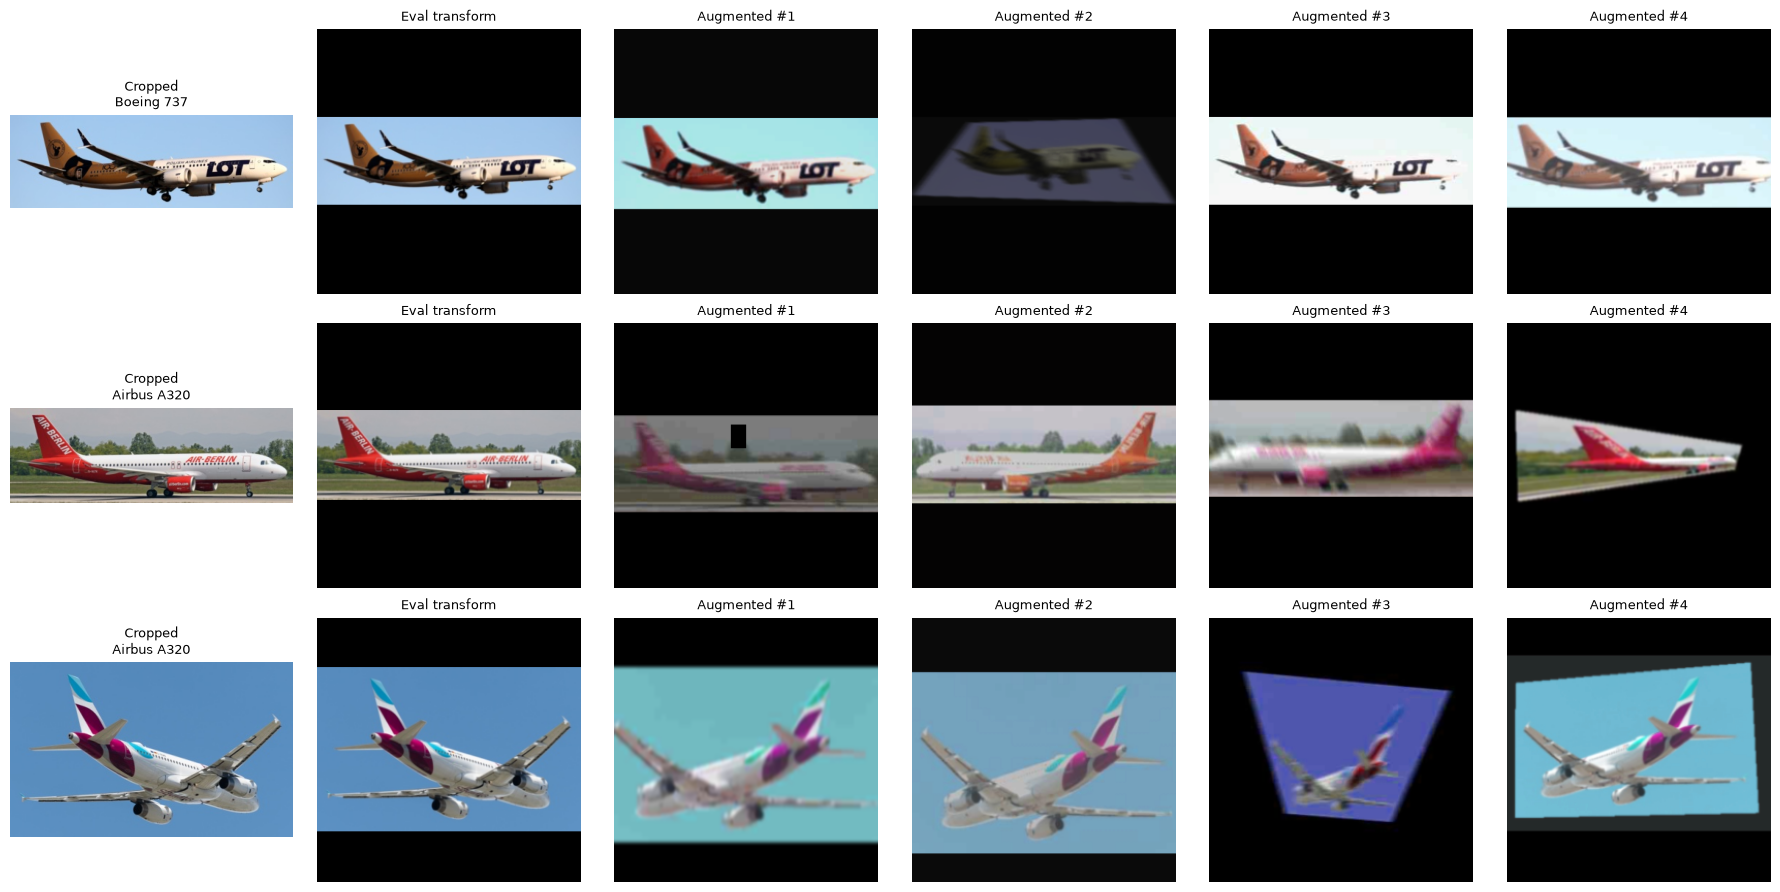

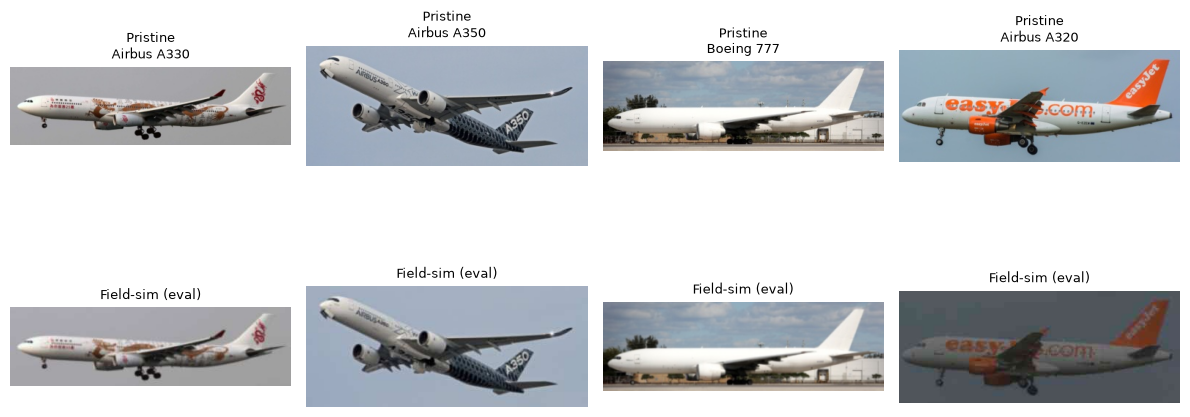

In [18]:
import matplotlib.pyplot as plt

def denormalize(tensor, mean=NORM_MEAN, std=NORM_STD):
    """Reverse Normalize(mean, std) so a tensor can be plotted as an image."""
    tensor = tensor.clone()
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return tensor.clamp(0, 1)

def show_augmentation_samples(samples, num_samples=3, num_augmented=4):
    indices = np.random.choice(len(samples), size=num_samples, replace=False)
    num_cols = 2 + num_augmented
    fig, axes = plt.subplots(num_samples, num_cols, figsize=(3 * num_cols, 3 * num_samples))
    if num_samples == 1:
        axes = axes[np.newaxis, :]
    for row, idx in enumerate(indices):
        orig_path, label = samples[idx]
        crop_path = crop_path_for(orig_path)
        path = crop_path if os.path.exists(crop_path) else orig_path
        raw = Image.open(path).convert("RGB")

        axes[row, 0].imshow(raw)
        axes[row, 0].set_title(f"Cropped\n{classes[label]}", fontsize=9)
        axes[row, 0].axis("off")

        eval_tensor = augmenter(raw, augment=False)
        axes[row, 1].imshow(denormalize(eval_tensor).permute(1, 2, 0).numpy())
        axes[row, 1].set_title("Eval transform", fontsize=9)
        axes[row, 1].axis("off")

        for col in range(num_augmented):
            aug_tensor = augmenter(raw, augment=True)
            axes[row, 2 + col].imshow(denormalize(aug_tensor).permute(1, 2, 0).numpy())
            axes[row, 2 + col].set_title(f"Augmented #{col + 1}", fontsize=9)
            axes[row, 2 + col].axis("off")
    plt.tight_layout()
    plt.show()

show_augmentation_samples(train_samples, num_samples=3, num_augmented=4)


def show_fieldsim_samples(samples, num_samples=4):
    """Deterministic field-sim eval views (what the honest metric actually scores) next to the
    pristine crop -- eyeball that these resemble a phone pointed at a distant landing plane."""
    from plane_data import stable_seed
    indices = np.random.choice(len(samples), size=num_samples, replace=False)
    fig, axes = plt.subplots(2, num_samples, figsize=(3 * num_samples, 6))
    for col, idx in enumerate(indices):
        orig_path, label = samples[idx]
        base = os.path.basename(orig_path)
        path = crop_path_for(orig_path) if os.path.exists(crop_path_for(orig_path)) else orig_path
        raw = Image.open(path).convert("RGB")
        axes[0, col].imshow(raw); axes[0, col].axis("off")
        axes[0, col].set_title(f"Pristine\n{classes[label]}", fontsize=9)
        corrupted = eval_field_corruptions(raw, seed=stable_seed(base))
        axes[1, col].imshow(corrupted); axes[1, col].axis("off")
        axes[1, col].set_title("Field-sim (eval)", fontsize=9)
    plt.tight_layout(); plt.show()

show_fieldsim_samples(val_samples, num_samples=4)

### 11. Phase 2 – MobileNetV4 classifier

[MobileNetV4](https://arxiv.org/abs/2404.10518) (via `timm`, ImageNet-pretrained) is a newer mobile backbone that beats MobileNetV2 on the accuracy/latency trade-off. We load `MODEL_NAME`, give it a fresh head sized for our `NUM_CLASSES` model families, and first train just that head with the backbone frozen (a linear probe). `timm.create_model(..., num_classes=...)` builds the correctly-sized head for us.

Note the input size and normalisation must match the pretrained weights — that's why the config uses 256×256 and ImageNet `NORM_MEAN`/`NORM_STD` for `mobilenetv4_conv_medium`.

In [12]:
import timm

def build_classifier(num_classes: int, model_name: str = MODEL_NAME,
                     freeze_base: bool = True, drop_rate: float = 0.2):
    """
    Create a timm MobileNetV4 with an ImageNet-pretrained backbone and a fresh head
    sized for `num_classes`. If `freeze_base`, everything except the final classifier
    is frozen so we can warm up the head first (a linear probe).
    """
    model = timm.create_model(
        model_name, pretrained=True, num_classes=num_classes, drop_rate=drop_rate
    )
    if freeze_base:
        for p in model.parameters():
            p.requires_grad = False
        for p in model.get_classifier().parameters():
            p.requires_grad = True
    return model

model = build_classifier(NUM_CLASSES, freeze_base=True).to(DEVICE)

# Sanity-check the head and confirm the preprocessing our augmenter must match.
data_cfg = timm.data.resolve_model_data_config(model)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Model: {MODEL_NAME}  |  params: {total:,}  |  trainable (head only): {trainable:,}")
print("Classifier head:", model.get_classifier())
print("Pretrained expects  input:", data_cfg["input_size"], " mean:", data_cfg["mean"], " std:", data_cfg["std"])
assert tuple(data_cfg["mean"]) == tuple(NORM_MEAN) and tuple(data_cfg["std"]) == tuple(NORM_STD), \
    "NORM_MEAN/NORM_STD in the config cell don't match this model's expected normalisation."

model.safetensors:   0%|          | 0.00/39.2M [00:00<?, ?B/s]

Model: mobilenetv4_conv_medium  |  params: 8,455,008  |  trainable (head only): 20,496
Classifier head: Linear(in_features=1280, out_features=16, bias=True)
Pretrained expects  input: (3, 256, 256)  mean: (0.485, 0.456, 0.406)  std: (0.229, 0.224, 0.225)


### 12. Training infrastructure + head warm-up

This section defines the shared training/eval helpers and runs the **head-only warm-up** (linear probe: backbone frozen, only the new head trains).

**Recipe** (used here and in the fine-tune below):
- **Optimizer:** `AdamW` with weight decay (real regularisation the old plain `Adam` lacked).
- **Schedule:** `OneCycleLR` (warm-up → cosine decay), stepped per batch.
- **Loss:** cross-entropy with **label smoothing**; on the fine-tune, **MixUp/CutMix** soft targets.
- **Imbalance:** handled upstream by the balanced `WeightedRandomSampler` (Section 10), so the loss is *unweighted* — we don't stack both.

**Selection metric — the important change:** we report both **pristine-val** F1 (sanity) and **field-sim** F1 (the deployment-representative proxy), and keep the best checkpoint by **field-sim macro-F1**. Optimising pristine-val would tune the model to clean, side-on, high-detail photos it will never see in the app.

In [13]:
import copy
import numpy as np
import torch.optim as optim
from torch import nn

# --- MixUp / CutMix (soft targets) via timm; degrade gracefully if unavailable -------------
try:
    from timm.data import Mixup
    from timm.loss import SoftTargetCrossEntropy
    mixup_fn = Mixup(
        mixup_alpha=MIXUP_ALPHA, cutmix_alpha=CUTMIX_ALPHA, prob=MIXUP_PROB,
        switch_prob=0.5, mode="batch", label_smoothing=LABEL_SMOOTHING,
        num_classes=NUM_CLASSES,
    )
    soft_criterion = SoftTargetCrossEntropy()
    print("MixUp/CutMix enabled.")
except Exception as e:
    mixup_fn, soft_criterion = None, None
    print(f"MixUp unavailable ({e}); training without it.")

# Hard-label loss (label-smoothed). Imbalance is handled by the balanced sampler, so NO class
# weights here -- stacking a balanced sampler AND inverse-freq weights double-counts.
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)


@torch.no_grad()
def evaluate(model, loader, return_per_class=False):
    """Loss / accuracy / macro-F1 on a loader. macro-F1 = mean per-class F1 -- the honest
    metric under imbalance (a majority-only predictor scores very low)."""
    model.eval()
    running_loss, total = 0.0, 0
    tp = np.zeros(NUM_CLASSES); support = np.zeros(NUM_CLASSES); predicted = np.zeros(NUM_CLASSES)
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        running_loss += criterion(outputs, labels).item() * images.size(0)
        total += images.size(0)
        l = labels.cpu().numpy(); p = outputs.argmax(1).cpu().numpy()
        np.add.at(support, l, 1); np.add.at(predicted, p, 1)
        np.add.at(tp, l, (l == p).astype(int))
    precision = np.divide(tp, predicted, out=np.zeros(NUM_CLASSES), where=predicted > 0)
    recall = np.divide(tp, support, out=np.zeros(NUM_CLASSES), where=support > 0)
    f1 = np.divide(2 * precision * recall, precision + recall,
                   out=np.zeros(NUM_CLASSES), where=(precision + recall) > 0)
    macro_f1 = float(f1[support > 0].mean())
    if return_per_class:
        return running_loss / total, tp.sum() / total, macro_f1, precision, recall, f1, support
    return running_loss / total, tp.sum() / total, macro_f1


def train_one_epoch(model, optimizer, scheduler=None, use_mixup=True):
    model.train()
    running_loss, total = 0.0, 0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        # MixUp needs an even batch; the last (odd) batch just trains on hard labels.
        if use_mixup and mixup_fn is not None and images.size(0) % 2 == 0:
            mixed, soft_targets = mixup_fn(images, labels)
            loss = soft_criterion(model(mixed), soft_targets)
        else:
            loss = criterion(model(images), labels)
        loss.backward(); optimizer.step()
        if scheduler is not None:
            scheduler.step()
        running_loss += loss.item() * images.size(0); total += images.size(0)
    return running_loss / total


# Global best-checkpoint tracking, shared across the warm-up and fine-tune phases and keyed on
# FIELD-SIM macro-F1 (deployment proxy), NOT pristine-val.
best_field_f1 = 0.0
best_model_weights = None
history = []

def fit(model, optimizer, epochs, phase, use_mixup=True):
    """Run `epochs` with a OneCycle schedule; log pristine + field-sim metrics each epoch and
    keep the global best checkpoint by field-sim macro-F1."""
    global best_field_f1, best_model_weights
    if best_model_weights is None:
        best_model_weights = copy.deepcopy(model.state_dict())
    max_lrs = [g["lr"] for g in optimizer.param_groups]
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=max_lrs, total_steps=len(train_loader) * epochs, pct_start=0.1,
    )
    for ep in range(epochs):
        tr_loss = train_one_epoch(model, optimizer, scheduler, use_mixup)
        _, p_acc, p_f1 = evaluate(model, val_loader)         # pristine (sanity)
        _, f_acc, f_f1 = evaluate(model, val_field_loader)   # field-sim (SELECTION)
        history.append((phase, ep, tr_loss, p_acc, p_f1, f_acc, f_f1))
        star = ""
        if f_f1 > best_field_f1:
            best_field_f1 = f_f1
            best_model_weights = copy.deepcopy(model.state_dict())
            star = "  <-- best (field-sim)"
        print(f"[{phase}] Ep {ep+1:2d}/{epochs} | train {tr_loss:.3f} | "
              f"pristine acc {p_acc:.3f} F1 {p_f1:.3f} | "
              f"FIELD-SIM acc {f_acc:.3f} F1 {f_f1:.3f}{star}")
    return best_field_f1


# ---- Head warm-up (linear probe): backbone frozen, MixUp off (it hurts a pure linear probe).
head_optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=HEAD_LR, weight_decay=WEIGHT_DECAY,
)
fit(model, head_optimizer, HEAD_EPOCHS, phase="head", use_mixup=False)
print(f"\nBest field-sim macro-F1 after head warm-up: {best_field_f1:.4f}")

MixUp/CutMix enabled.
[head] Ep  1/4 | train 5.210 | pristine acc 0.247 F1 0.092 | FIELD-SIM acc 0.261 F1 0.113  <-- best (field-sim)
[head] Ep  2/4 | train 3.704 | pristine acc 0.290 F1 0.118 | FIELD-SIM acc 0.308 F1 0.153  <-- best (field-sim)
[head] Ep  3/4 | train 3.196 | pristine acc 0.318 F1 0.131 | FIELD-SIM acc 0.339 F1 0.171  <-- best (field-sim)
[head] Ep  4/4 | train 3.058 | pristine acc 0.335 F1 0.140 | FIELD-SIM acc 0.362 F1 0.172  <-- best (field-sim)

Best field-sim macro-F1 after head warm-up: 0.1722


### 13. Fine-tuning: unfreeze the backbone (discriminative LR)

Unfreeze the whole backbone and fine-tune end-to-end. We use **discriminative learning rates** — a low LR for the ImageNet-pretrained backbone (`FT_BACKBONE_LR`) so we don't wreck its features, and a higher LR for the fresh head (`FT_HEAD_LR`) which still has more to learn. **MixUp/CutMix** is on for this phase. This is where most of the accuracy comes from; it runs for `FINE_TUNE_EPOCHS` with the best checkpoint kept by **field-sim macro-F1**.

In [14]:
# Unfreeze the whole backbone.
for p in model.parameters():
    p.requires_grad = True

# Discriminative LR: split params into head vs backbone by identity (robust across
# architectures -- get_classifier() returns whatever the current backbone's head is).
head_ids = {id(p) for p in model.get_classifier().parameters()}
head_params     = [p for p in model.parameters() if id(p) in head_ids]
backbone_params = [p for p in model.parameters() if id(p) not in head_ids]

ft_optimizer = optim.AdamW(
    [
        {"params": backbone_params, "lr": FT_BACKBONE_LR},
        {"params": head_params,     "lr": FT_HEAD_LR},
    ],
    weight_decay=WEIGHT_DECAY,
)

fit(model, ft_optimizer, FINE_TUNE_EPOCHS, phase="fine-tune", use_mixup=True)

# Restore the globally-best checkpoint (may be from any epoch of either phase).
model.load_state_dict(best_model_weights)
print(f"\nBest field-sim macro-F1 (all phases): {best_field_f1:.4f}")

[fine-tune] Ep  1/20 | train 2.668 | pristine acc 0.586 F1 0.330 | FIELD-SIM acc 0.575 F1 0.332  <-- best (field-sim)
[fine-tune] Ep  2/20 | train 2.266 | pristine acc 0.705 F1 0.494 | FIELD-SIM acc 0.683 F1 0.485  <-- best (field-sim)
[fine-tune] Ep  3/20 | train 1.923 | pristine acc 0.282 F1 0.082 | FIELD-SIM acc 0.265 F1 0.047
[fine-tune] Ep  4/20 | train 1.985 | pristine acc 0.737 F1 0.606 | FIELD-SIM acc 0.747 F1 0.615  <-- best (field-sim)
[fine-tune] Ep  5/20 | train 1.871 | pristine acc 0.511 F1 0.206 | FIELD-SIM acc 0.482 F1 0.184
[fine-tune] Ep  6/20 | train 1.835 | pristine acc 0.753 F1 0.605 | FIELD-SIM acc 0.751 F1 0.625  <-- best (field-sim)
[fine-tune] Ep  7/20 | train 1.985 | pristine acc 0.700 F1 0.529 | FIELD-SIM acc 0.695 F1 0.539
[fine-tune] Ep  8/20 | train 1.744 | pristine acc 0.845 F1 0.762 | FIELD-SIM acc 0.845 F1 0.755  <-- best (field-sim)
[fine-tune] Ep  9/20 | train 1.664 | pristine acc 0.861 F1 0.807 | FIELD-SIM acc 0.863 F1 0.790  <-- best (field-sim)
[fin

In [15]:
# Persist the best checkpoint together with everything needed to reload it for inference/export
# (class order, input size, normalisation, backbone name).
CKPT_PATH = "plane_classifier_checkpoint.pt"
torch.save({
    "state_dict": best_model_weights,
    "model_name": MODEL_NAME,
    "classes": classes,
    "img_size": (IMG_HEIGHT, IMG_WIDTH),
    "norm_mean": NORM_MEAN,
    "norm_std": NORM_STD,
    "best_field_f1": best_field_f1,
}, CKPT_PATH)
print(f"Saved {CKPT_PATH}  (field-sim macro-F1 {best_field_f1:.4f}, backbone {MODEL_NAME})")

Saved plane_classifier_checkpoint.pt  (field-sim macro-F1 0.9043, backbone mobilenetv4_conv_medium)


In [16]:
# --- Reload the trained model from the checkpoint (skip retraining after a kernel restart) ---
# Run this instead of the training cells (28-31) to get a ready-to-use `model` from disk. It
# restores the backbone, weights, class order, input size and normalisation straight from the
# .pt file, so every inference / eval / export cell below works immediately. Needs only the
# config cell above (for DEVICE); for actual image inference also run the augmenter cell
# (eval_augmenter) and the YOLO cell (detect_and_crop_aircraft).
import torch, timm

CKPT_PATH = "plane_classifier_checkpoint.pt"
DEVICE = globals().get("DEVICE", "cuda" if torch.cuda.is_available() else "cpu")

_ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)  # our own trusted file
classes               = _ckpt["classes"]
NUM_CLASSES           = len(classes)
MODEL_NAME            = _ckpt["model_name"]
IMG_HEIGHT, IMG_WIDTH = _ckpt["img_size"]
NORM_MEAN             = tuple(_ckpt["norm_mean"])
NORM_STD              = tuple(_ckpt["norm_std"])

model = timm.create_model(MODEL_NAME, pretrained=False, num_classes=NUM_CLASSES)
model.load_state_dict(_ckpt["state_dict"])          # strict: fails loudly on any mismatch
model = model.to(DEVICE).eval()

print(f"Loaded {CKPT_PATH}\n  backbone {MODEL_NAME} | {NUM_CLASSES} classes | "
      f"input {IMG_HEIGHT}x{IMG_WIDTH} | field-sim macro-F1 {_ckpt.get('best_field_f1', float('nan')):.4f}")
print("  classes:", classes)

Loaded plane_classifier_checkpoint.pt
  backbone mobilenetv4_conv_medium | 16 classes | input 256x256 | field-sim macro-F1 0.9043
  classes: ['Airbus A220', 'Airbus A310', 'Airbus A320', 'Airbus A330', 'Airbus A340', 'Airbus A350', 'Airbus A380', 'Boeing 737', 'Boeing 747', 'Boeing 757', 'Boeing 767', 'Boeing 777', 'Boeing 787', 'Bombardier CRJ', 'Embraer E-Jet', 'McDonnell Douglas MD-80/90']


In [17]:
# --- Real-photo smoke test (deployment reality check) --------------------------------------
# Drop a few real PHONE photos of landing planes into dataset/field_real/, named like
# "<TrueType>__anything.jpg" (e.g. "Boeing 737__ryanair_approach.jpg"). These are NEVER
# trained or tuned on -- they exist only to confirm the field-sim proxy tracks reality and to
# sanity-check the abstain threshold. The true type before "__" is optional.
import glob as _glob
from PIL import Image as _Image

FIELD_REAL_DIR = os.path.join(DATA_DIR, "field_real")
os.makedirs(FIELD_REAL_DIR, exist_ok=True)

@torch.no_grad()
def predict_pil(pil_img, crop=True, tta=False):
    """Run the trained classifier on a raw PIL photo the way the app would: optional YOLO
    crop -> eval letterbox/normalise -> softmax. `tta` adds a horizontal-flip average."""
    model.eval()
    img = detect_and_crop_aircraft(pil_img) if crop else pil_img
    x = eval_augmenter(img, augment=False).unsqueeze(0).to(DEVICE)
    logits = model(x)
    if tta:
        logits = logits + model(torch.flip(x, dims=[3]))
    return torch.softmax(logits, dim=1)[0].cpu().numpy()

real_paths = sorted(p for p in _glob.glob(os.path.join(FIELD_REAL_DIR, "*"))
                    if p.lower().endswith((".jpg", ".jpeg", ".png", ".heic", ".webp")))
if not real_paths:
    print(f"(No real photos yet.) Add phone shots of landing planes to:\n  {FIELD_REAL_DIR}\n"
          f"Name them '<TrueType>__note.jpg' to see whether predictions are correct.")
else:
    correct = 0
    for p in real_paths:
        true = os.path.basename(p).split("__")[0] if "__" in os.path.basename(p) else None
        probs = predict_pil(_Image.open(p).convert("RGB"), crop=True, tta=True)
        top3 = probs.argsort()[-3:][::-1]
        tag = ""
        if true is not None:
            hit = classes[top3[0]] == true
            correct += int(hit); tag = "  OK" if hit else f"  MISS (true={true})"
        print(f"{os.path.basename(p)[:40]:40s} -> " +
              ", ".join(f"{classes[i]} {probs[i]:.2f}" for i in top3) + tag)
    labelled = [p for p in real_paths if "__" in os.path.basename(p)]
    if labelled:
        print(f"\nReal-photo top-1 accuracy: {correct}/{len(labelled)} = {correct/len(labelled):.2f}")

(No real photos yet.) Add phone shots of landing planes to:
  /home/theo/repos/plane-classifier/dataset/field_real
Name them '<TrueType>__note.jpg' to see whether predictions are correct.


### 14. Evaluate on the test set (pristine **and** field-sim)

The test set was sealed during all tuning. We report it **two ways**:

- **Pristine test** — same planespotter domain as training. Comparable to old numbers, but *optimistic* for deployment.
- **Field-sim test** — the same held-out images pushed through the deployment corruptions. **This is the number that matters** for "someone points a phone at a landing plane."

Expect field-sim < pristine; the *gap* is your domain-shift tax. Beyond raw accuracy we print **macro-F1**, a **per-class precision/recall/F1** table, and a **row-normalised confusion matrix** (bright columns under A320/737 = majority-class coasting).

PRISTINE  test | acc 0.9321 | macro-F1 0.9043
FIELD-SIM test | acc 0.9308 | macro-F1 0.9045
domain-shift tax: --0.0002 macro-F1  (pristine -> field-sim)

FIELD-SIM per-class (the deployment reality):
class                         prec recall    f1  support
Airbus A320                   0.92   0.97  0.95     1232
Boeing 737                    0.98   0.95  0.97      851
Boeing 777                    0.90   0.88  0.89      226
Airbus A330                   0.92   0.86  0.89      222
Embraer E-Jet                 0.90   0.91  0.90      133
Boeing 767                    0.91   0.81  0.86      129
Boeing 747                    0.93   0.90  0.91      112
Boeing 787                    0.88   0.89  0.88      108
Boeing 757                    0.96   0.81  0.88       86
Bombardier CRJ                0.98   0.98  0.98       54
Airbus A340                   0.93   0.83  0.88       52
Airbus A350                   0.84   0.92  0.88       39
Airbus A380                   0.81   0.88  0.84       33
Mc

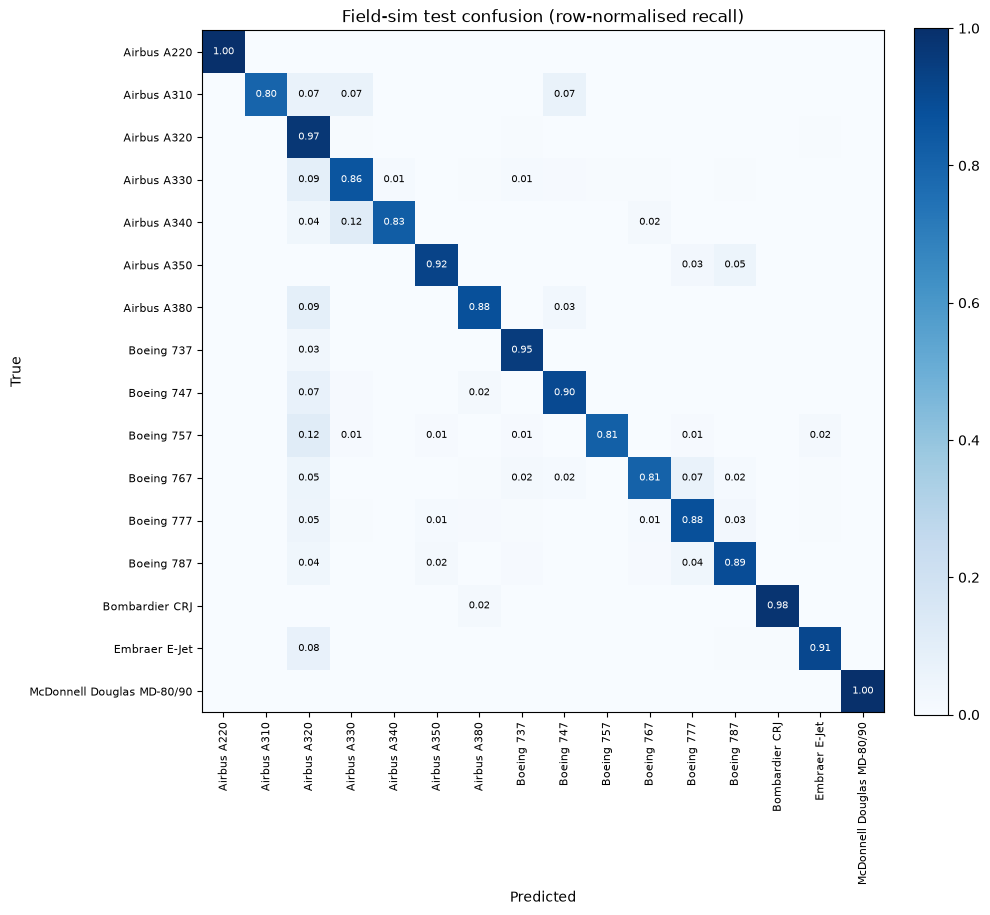


PRISTINE per-class (for reference):
class                         prec recall    f1  support
Airbus A320                   0.92   0.97  0.94     1232
Boeing 737                    0.98   0.95  0.96      851
Boeing 777                    0.93   0.86  0.89      226
Airbus A330                   0.93   0.87  0.90      222
Embraer E-Jet                 0.86   0.93  0.89      133
Boeing 767                    0.89   0.81  0.85      129
Boeing 747                    0.94   0.92  0.93      112
Boeing 787                    0.92   0.90  0.91      108
Boeing 757                    0.91   0.85  0.88       86
Bombardier CRJ                0.98   0.98  0.98       54
Airbus A340                   0.96   0.83  0.89       52
Airbus A350                   0.88   0.95  0.91       39
Airbus A380                   0.78   0.88  0.83       33
McDonnell Douglas MD-80/90    0.96   1.00  0.98       24
Airbus A310                   0.91   0.67  0.77       15
Airbus A220                   0.91   1.00  0.95    

In [18]:
import matplotlib.pyplot as plt

@torch.no_grad()
def collect_predictions(model, loader):
    model.eval()
    ys, ps = [], []
    for images, labels in loader:
        preds = model(images.to(DEVICE)).argmax(1).cpu()
        ys.append(labels); ps.append(preds)
    return torch.cat(ys).numpy(), torch.cat(ps).numpy()

def classification_report(y_true, y_pred, class_names):
    n = len(class_names)
    cm = np.zeros((n, n), dtype=int)
    np.add.at(cm, (y_true, y_pred), 1)
    tp = np.diag(cm).astype(float)
    support = cm.sum(1)
    precision = np.divide(tp, cm.sum(0), out=np.zeros(n), where=cm.sum(0) > 0)
    recall = np.divide(tp, support, out=np.zeros(n), where=support > 0)
    f1 = np.divide(2 * precision * recall, precision + recall,
                   out=np.zeros(n), where=(precision + recall) > 0)
    print(f"{'class':28s} {'prec':>5} {'recall':>6} {'f1':>5} {'support':>8}")
    for i in np.argsort(-support):
        print(f"{class_names[i]:28s} {precision[i]:5.2f} {recall[i]:6.2f} {f1[i]:5.2f} {support[i]:8d}")
    seen = support > 0
    print("-" * 56)
    print(f"{'accuracy (raw)':28s} {tp.sum() / cm.sum():5.2f}")
    print(f"{'balanced accuracy':28s} {recall[seen].mean():5.2f}")
    print(f"{'macro F1':28s} {f1[seen].mean():5.2f}   <- selection metric (honest under imbalance)")
    return cm

def plot_confusion_matrix(cm, class_names, title):
    m = cm.astype(float)
    row = m.sum(1, keepdims=True)
    m = np.divide(m, row, out=np.zeros_like(m), where=row > 0)   # row-normalise (recall)
    size = 1.2 + 0.55 * len(class_names)
    fig, ax = plt.subplots(figsize=(size, size))
    im = ax.imshow(m, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(class_names))); ax.set_xticklabels(class_names, rotation=90, fontsize=8)
    ax.set_yticks(range(len(class_names))); ax.set_yticklabels(class_names, fontsize=8)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title)
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            if m[i, j] > 0.01:
                ax.text(j, i, f"{m[i, j]:.2f}", ha="center", va="center",
                        fontsize=7, color="white" if m[i, j] > 0.5 else "black")
    fig.colorbar(im, fraction=0.046, pad=0.04)
    plt.tight_layout(); plt.show()

# Headline numbers on BOTH domains. Field-sim is the deployment-representative one.
p_loss, p_acc, p_f1 = evaluate(model, test_loader)
f_loss, f_acc, f_f1 = evaluate(model, test_field_loader)
print(f"PRISTINE  test | acc {p_acc:.4f} | macro-F1 {p_f1:.4f}")
print(f"FIELD-SIM test | acc {f_acc:.4f} | macro-F1 {f_f1:.4f}")
print(f"domain-shift tax: -{p_f1 - f_f1:.4f} macro-F1  (pristine -> field-sim)\n")

print("=" * 56, "\nFIELD-SIM per-class (the deployment reality):")
yf_true, yf_pred = collect_predictions(model, test_field_loader)
cm_field = classification_report(yf_true, yf_pred, classes)
plot_confusion_matrix(cm_field, classes, "Field-sim test confusion (row-normalised recall)")

print("\n" + "=" * 56, "\nPRISTINE per-class (for reference):")
yp_true, yp_pred = collect_predictions(model, test_loader)
cm_pristine = classification_report(yp_true, yp_pred, classes)

### 15b. Open-set: abstain on unknown aircraft

Softmax always names one of the 14 families, but the app will be pointed at A220s, turboprops, helicopters, birds — things it was never trained on. So we (1) **temperature-scale** the logits for honest confidence, then (2) pick an **abstain threshold** on max-probability, calibrated so we keep ~90% of genuine in-distribution inputs while rejecting as many of the held-out non-jet images (`ood_samples`, a free by-product of the caption filtering) as possible. Below the threshold the app should say *"not sure"* rather than guess.

In [17]:
import random
from torch.utils.data import DataLoader
from plane_data import AircraftDataset

@torch.no_grad()
def collect_logits(loader, max_batches=None):
    model.eval(); logits, ys = [], []
    for i, (x, y) in enumerate(loader):
        logits.append(model(x.to(DEVICE)).cpu()); ys.append(y)
        if max_batches and i + 1 >= max_batches:
            break
    return torch.cat(logits), torch.cat(ys)

# 1) Temperature scaling: fit a single scalar T on pristine-val logits to calibrate confidence.
val_logits, val_labels = collect_logits(val_loader)
_T = torch.nn.Parameter(torch.ones(1))
_opt = torch.optim.LBFGS([_T], lr=0.01, max_iter=60)
_nll = torch.nn.CrossEntropyLoss()
def _closure():
    _opt.zero_grad(); loss = _nll(val_logits / _T.clamp(min=1e-2), val_labels); loss.backward(); return loss
_opt.step(_closure)
TEMP = float(_T.detach().clamp(min=1e-2))
print(f"Fitted temperature T = {TEMP:.3f}")

def confidence(logits, temp=None):
    return torch.softmax(logits / (temp or TEMP), dim=1).max(1).values

# 2) In-distribution (field-sim val) vs OOD (held-out non-jet images) confidence.
ood_pick = [(p, 0) for p in random.sample(ood_samples, k=min(800, len(ood_samples)))]
ood_ds = AircraftDataset(ood_pick, eval_augmenter, augment=False, crop_dir=CROP_DIR,
                         field_corruptions=eval_field_corruptions)
ood_loader = DataLoader(ood_ds, batch_size=BATCH_SIZE, shuffle=False)

id_conf  = confidence(collect_logits(val_field_loader)[0]).numpy()
ood_conf = confidence(collect_logits(ood_loader)[0]).numpy()

# 3) Threshold that keeps ~90% of in-distribution inputs; measure OOD rejection there.
KEEP_INDIST = 0.90
ABSTAIN_THRESHOLD = float(np.quantile(id_conf, 1 - KEEP_INDIST))
ood_reject = float((ood_conf < ABSTAIN_THRESHOLD).mean())
print(f"Abstain threshold (calibrated conf) = {ABSTAIN_THRESHOLD:.3f}  "
      f"[keep {KEEP_INDIST:.0%} of in-distribution]")
print(f"  -> rejects {ood_reject:.1%} of unknown-aircraft inputs as 'not sure'")
print(f"  in-dist median conf {np.median(id_conf):.2f} | OOD median conf {np.median(ood_conf):.2f}")

Fitted temperature T = 1.330
Abstain threshold (calibrated conf) = 0.406  [keep 90% of in-distribution]
  -> rejects 74.2% of unknown-aircraft inputs as 'not sure'
  in-dist median conf 0.67 | OOD median conf 0.29


### 15c. Live multi-frame temporal aggregation

A single hand-held frame of a distant plane is often junk, but the camera streams ~30/s. Averaging the calibrated per-frame probabilities over a short sliding window (and only committing once the aggregated confidence clears the abstain threshold) turns many weak, flickering guesses into one stable answer — the biggest *free* robustness win on-device. Below we simulate a burst of frames by re-corrupting the same held-out image with different seeds, and compare single-frame vs aggregated field-sim accuracy.

In [18]:
from plane_data import stable_seed

class TemporalAggregator:
    """Sliding-window average of calibrated per-frame probabilities for the live camera.

    Feed one frame's logits at a time via `update`; it returns (class_idx_or_None, confidence).
    It stays undecided ("not sure") until it has seen `min_frames` and the aggregated top
    probability clears `threshold` -- so a few blurry frames can't force a wrong, jumpy answer.
    """
    def __init__(self, window=8, temp=None, threshold=None, min_frames=3):
        self.window = window
        self.temp = temp if temp is not None else TEMP
        self.threshold = threshold if threshold is not None else ABSTAIN_THRESHOLD
        self.min_frames = min_frames
        self.buf = []

    def update(self, logits):
        p = torch.softmax(logits.flatten() / self.temp, dim=0)
        self.buf.append(p)
        if len(self.buf) > self.window:
            self.buf.pop(0)
        avg = torch.stack(self.buf).mean(0)
        conf, idx = avg.max(0)
        decided = len(self.buf) >= self.min_frames and conf.item() >= self.threshold
        return (idx.item() if decided else None), conf.item()

    def reset(self):
        self.buf = []

# --- Demo: single-frame vs 8-frame aggregation on a field-sim "video" of val images ---------
FRAMES = 8
demo = random.sample(val_samples, k=min(150, len(val_samples)))
single_correct = agg_correct = agg_decided = 0
for orig_path, label in demo:
    base = os.path.basename(orig_path)
    cpath = os.path.join(CROP_DIR, base)
    raw = Image.open(cpath if os.path.exists(cpath) else orig_path).convert("RGB")
    agg = TemporalAggregator(window=FRAMES, min_frames=3)
    decided_idx = None
    for f in range(FRAMES):
        # Each "frame" = a different field-sim realisation of the same plane.
        frame = eval_field_corruptions(raw, seed=stable_seed(f"{base}#{f}"))
        x = eval_augmenter(frame, augment=False).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            logits = model(x).cpu()
        if f == 0:
            single_correct += int(logits.argmax().item() == label)
        decided_idx, _ = agg.update(logits)
    if decided_idx is not None:
        agg_decided += 1
        agg_correct += int(decided_idx == label)

n = len(demo)
print(f"Single-frame field-sim accuracy : {single_correct/n:.3f}")
print(f"{FRAMES}-frame aggregated accuracy   : {agg_correct/n:.3f} "
      f"(decided on {agg_decided}/{n}; the rest abstained as 'not sure')")
if agg_decided:
    print(f"  accuracy among DECIDED frames : {agg_correct/agg_decided:.3f}")

Single-frame field-sim accuracy : 0.913
8-frame aggregated accuracy   : 0.833 (decided on 135/150; the rest abstained as 'not sure')
  accuracy among DECIDED frames : 0.926


### 15d. Real Live-Photo frames: honest eval + real temporal aggregation

A single still of a distant plane is the worst case. Your iPhone **Live Photos** are ~3 s clips (~45 frames), so each capture is really a short burst of the *same* plane rotating through slightly different aspects — exactly what the app gets from a live camera. Dropping the `.MOV` halves into `dataset/field_video/` (named `<TrueType>__id.mov`) lets us:

1. build a **real** evaluation set (dozens of true frames from a few captures), replacing the misleading field-sim proxy;
2. measure **real temporal aggregation** (mean of per-frame probabilities) vs single-frame — the deployment-side win, on real data;
3. optionally hold some captures out to fine-tune on genuine below-angle frames later.

OpenCV decodes the `.MOV` directly (no ffmpeg needed). Frames are cached to `dataset/field_frames/` for inspection.

In [19]:
import cv2, glob
import numpy as np
from PIL import Image

FIELD_VIDEO_DIR  = os.path.join(DATA_DIR, "field_video")
FIELD_FRAMES_DIR = os.path.join(DATA_DIR, "field_frames")
os.makedirs(FIELD_VIDEO_DIR, exist_ok=True); os.makedirs(FIELD_FRAMES_DIR, exist_ok=True)

def extract_frames(video_path, n=12):
    """Sample up to n evenly-spaced RGB PIL frames from a Live Photo .MOV/.MP4 via OpenCV."""
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frames = []
    if total > 0:
        for i in np.linspace(0, total - 1, min(n, total)).astype(int):
            cap.set(cv2.CAP_PROP_POS_FRAMES, int(i))
            ok, fr = cap.read()
            if ok:
                frames.append(Image.fromarray(cv2.cvtColor(fr, cv2.COLOR_BGR2RGB)))
    else:                                   # container didn't report a frame count -> read all
        allf = []
        ok, fr = cap.read()
        while ok:
            allf.append(fr); ok, fr = cap.read()
        for i in np.linspace(0, len(allf) - 1, min(n, len(allf))).astype(int) if allf else []:
            frames.append(Image.fromarray(cv2.cvtColor(allf[int(i)], cv2.COLOR_BGR2RGB)))
    cap.release()
    return frames

N_FRAMES = 12
_temp = TEMP if "TEMP" in globals() else 1.0
videos = sorted(v for v in glob.glob(os.path.join(FIELD_VIDEO_DIR, "*"))
                if v.lower().endswith((".mov", ".mp4", ".m4v")))

if not videos:
    print(f"(No Live Photo videos yet.) Export the .MOV halves of your Live Photos to:\n"
          f"  {FIELD_VIDEO_DIR}\n"
          f"named '<TrueType>__id.mov' (e.g. 'Boeing 737__approach1.mov'), then re-run.")
else:
    single_hits = agg_hits = decided_hits = decided_n = 0
    for v in videos:
        true = os.path.basename(v).split("__")[0]
        frames = extract_frames(v, N_FRAMES)
        if not frames:
            print(f"{os.path.basename(v)[:34]:34s} could not decode"); continue
        agg = TemporalAggregator(window=N_FRAMES, min_frames=3)
        probs = []
        decided_idx = None
        for k, fr in enumerate(frames):
            cropped = detect_and_crop_aircraft(fr)
            x = eval_augmenter(cropped, augment=False).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                logits = model(x).cpu()
            probs.append(torch.softmax(logits.flatten() / _temp, 0).numpy())
            d, _ = agg.update(logits)
            if d is not None and decided_idx is None:
                decided_idx = d
        probs = np.array(probs)
        single = probs[len(probs) // 2].argmax()        # a representative single frame
        aggreg = probs.mean(0).argmax()                   # temporal aggregation
        single_hits += (classes[single] == true)
        agg_hits += (classes[aggreg] == true)
        if decided_idx is not None:
            decided_n += 1; decided_hits += (classes[decided_idx] == true)
        # cache the middle frame for inspection
        frames[len(frames) // 2].save(os.path.join(FIELD_FRAMES_DIR,
            os.path.splitext(os.path.basename(v))[0] + "_mid.jpg"))
        print(f"{os.path.basename(v)[:32]:32s} true {true:12s} | single {classes[single]:12s} "
              f"| AGG {classes[aggreg]:12s} conf {probs.mean(0).max():.2f} | {len(frames)} frames")
    n = len(videos)
    print(f"\nREAL single-frame acc : {single_hits/n:.2f}")
    print(f"REAL temporal-agg acc : {agg_hits/n:.2f}   (n={n} clips)")
    if decided_n:
        print(f"with abstain: answered {decided_n}/{n}, acc-among-answered {decided_hits/decided_n:.2f}")

Airbus A320__IMG_0955.MOV        true Airbus A320  | single Boeing 787   | AGG Airbus A320  conf 0.14 | 12 frames
Airbus A320__IMG_0956.MOV        true Airbus A320  | single Airbus A320  | AGG Airbus A320  conf 0.28 | 11 frames
Airbus A320__IMG_0958.MOV        true Airbus A320  | single Airbus A320  | AGG Airbus A320  conf 0.56 | 12 frames
Airbus A320__IMG_0978.MOV        true Airbus A320  | single Airbus A320  | AGG Airbus A320  conf 0.64 | 12 frames
Airbus A380__IMG_0663.MOV        true Airbus A380  | single Airbus A380  | AGG Airbus A380  conf 0.66 | 12 frames
Airbus A380__IMG_0664.MOV        true Airbus A380  | single Airbus A380  | AGG Airbus A380  conf 0.42 | 11 frames
Airbus A380__IMG_0959.MOV        true Airbus A380  | single Boeing 747   | AGG Boeing 747   conf 0.26 | 11 frames
Boeing 747__IMG_0953.MOV         true Boeing 747   | single Boeing 747   | AGG Boeing 747   conf 0.64 | 12 frames
Boeing 767__IMG_0960.MOV         true Boeing 767   | single Airbus A350  | AGG Airbus A3

### 15. Export the model for mobile deployment

Target is **iPhone**, so the primary artifact is **Core ML** (`.mlpackage`) — it runs on the Apple Neural Engine (ANE) for real-time, low-power live-camera inference. We also keep cross-platform exports:
- **Core ML** (`.mlpackage`) — **recommended for this app**; ANE-accelerated, and the only way to get an honest on-device latency/power number (measure it in Xcode Instruments).
- **TorchScript** (`.pt`) — PyTorch Mobile / ExecuTorch.
- **ONNX** (`.onnx`) — ONNX Runtime; bridges to other runtimes.
- **TensorFlow Lite** (`.tflite`, optional) — Android, via `onnx2tf`.

We export on CPU so the artifacts aren't tied to CUDA. `class_names.txt` maps output indices back to family names.

**On-device preprocessing must match training:** resize to `IMG_HEIGHT`×`IMG_WIDTH`, scale to `[0,1]`, then normalise with `NORM_MEAN`/`NORM_STD`. For Core ML we **bake normalisation into the model** (via a wrapper + `ImageType(scale=1/255)`), so the app can hand it a plain image and read back class probabilities. Note the app should also run the same **YOLO crop** and, ideally, the **temporal aggregation + abstain threshold** from §15b/§15c around this model.

In [6]:
import copy

# TorchScript export (PyTorch Mobile). Trace on CPU so the artifact isn't CUDA-bound.
cpu_model = copy.deepcopy(model).cpu().eval()
example_input = torch.randn(1, 3, IMG_HEIGHT, IMG_WIDTH)

traced_model = torch.jit.trace(cpu_model, example_input)
traced_model.save("plane_classifier_mobilenetv4.pt")
print("Saved TorchScript model -> plane_classifier_mobilenetv4.pt")

# Save the class list (index -> family name) for the mobile app.
with open("class_names.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(classes))
print(f"Saved class_names.txt ({NUM_CLASSES} classes)")

Saved TorchScript model -> plane_classifier_mobilenetv4.pt
Saved class_names.txt (16 classes)


In [7]:
# --- Core ML export (iPhone / Apple Neural Engine) -----------------------------------------
# Bake ImageNet normalisation + softmax into a wrapper so the .mlpackage takes a plain image
# in [0,1] (ImageType scale=1/255) and returns calibrated class probabilities. ClassifierConfig
# attaches the family names so the app gets a labelled prediction directly.
try:
    import coremltools as ct

    class CoreMLWrapper(torch.nn.Module):
        def __init__(self, backbone, mean, std, temp=1.0):
            super().__init__()
            self.backbone = backbone
            self.register_buffer("mean", torch.tensor(mean).view(1, 3, 1, 1))
            self.register_buffer("std", torch.tensor(std).view(1, 3, 1, 1))
            self.temp = float(temp)

        def forward(self, x):                      # x in [0,1], NCHW
            x = (x - self.mean) / self.std
            return torch.softmax(self.backbone(x) / self.temp, dim=1)

    _temp = TEMP if "TEMP" in globals() else 1.0   # use calibrated temperature if available
    wrapper = CoreMLWrapper(copy.deepcopy(model).cpu().eval(), NORM_MEAN, NORM_STD, _temp).eval()
    example = torch.rand(1, 3, IMG_HEIGHT, IMG_WIDTH)
    traced = torch.jit.trace(wrapper, example)

    mlmodel = ct.convert(
        traced,
        inputs=[ct.ImageType(name="image", shape=example.shape, scale=1 / 255.0, bias=[0, 0, 0])],
        classifier_config=ct.ClassifierConfig(class_labels=list(classes)),
        compute_units=ct.ComputeUnit.ALL,          # let Core ML place ops on the ANE
        minimum_deployment_target=ct.target.iOS16,
    )
    mlmodel.short_description = "Commercial jet family classifier (MobileNetV4)"
    mlmodel.save("PlaneClassifier.mlpackage")
    print("Saved Core ML model -> PlaneClassifier.mlpackage")
    print("Measure real latency/power in Xcode Instruments (Core ML + Neural Engine template).")
except ImportError:
    print("coremltools not installed. To enable the iPhone export run:\n"
          "    pip install coremltools\n"
          "(then re-run this cell).")

Torch version 2.13.0 has not been tested with coremltools. You may run into unexpected errors. Torch 2.7.0 is the most recent version that has been tested.
Running MIL default pipeline:   0%|                                                        | 0/95 [00:00<?, ? passes/s]/Users/theoma/repos/plane-classifier/.venv/lib/python3.12/site-packages/coremltools/converters/mil/mil/passes/defs/preprocess.py:273: UserWarning: Output, '1196', of the source model, has been renamed to 'var_1196' in the Core ML model.
  warnings.warn(msg.format(var.name, new_name))
Running MIL backend_mlprogram pipeline: 100%|████████████████████████████████████| 12/12 [00:00<00:00, 297.73 passes/s]


Saved Core ML model -> PlaneClassifier.mlpackage
Measure real latency/power in Xcode Instruments (Core ML + Neural Engine template).


In [10]:
# ONNX export (ONNX Runtime Mobile, and a bridge to TFLite below).
torch.onnx.export(
    cpu_model,
    example_input,
    "plane_classifier_mobilenetv4.onnx",
    input_names=["input"],
    output_names=["output"],
    opset_version=17,
    dynamic_axes={"input": {0: "batch_size"}, "output": {0: "batch_size"}},
)
print("Saved ONNX model -> plane_classifier_mobilenetv4.onnx")

/var/folders/0z/jbdx170j7_bb72bz07tc98w00000gn/T/ipykernel_20882/3061688234.py:2: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0803 23:44:04.553000 20882 .venv/lib/python3.12/site-packages/torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `MobileNetV3([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MobileNetV3([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/Users/theoma/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


Failed to convert the model to the target version 17 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/Users/theoma/repos/plane-classifier/.venv/lib/python3.12/site-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/theoma/repos/plane-classifier/.venv/lib/python3.12/site-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/Users/theoma/repos/plane-classifier/.venv/lib/python3.12/site-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/theoma/repos/plane-classifier/.venv/lib/python3.12/site-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_

[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Saved ONNX model -> plane_classifier_mobilenetv4.onnx


### (Optional) Convert ONNX -> TensorFlow Lite for Android

`onnx2tf` is the current, actively-maintained ONNX -> TFLite converter. This writes several `.tflite` files (float32, float16, and dynamic-range-quantised) into `tflite_out/`; pick the quantised one for the smallest phone footprint.

In [ ]:
# Optional: requires TensorFlow. onnx2tf replaces the deprecated onnx-tf path.
%pip install -q onnx2tf onnx onnxsim tensorflow
!onnx2tf -i plane_classifier_mobilenetv4.onnx -o tflite_out
print("TFLite models written to tflite_out/")